In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Imported libraries for data visualization and manipulation.

In [ ]:
df = pd.read_csv('tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


CONCLUSION:-
Loaded the dataset and display the first few rows to understand the structure of the data.

In [ ]:
df.sample(5)

,total_bill,tip,sex,smoker,day,time,size
107,25.21,4.29,Male,Yes,Sat,Dinner,2
151,13.13,2.00,Male,No,Sun,Dinner,2
190,15.69,1.50,Male,Yes,Sun,Dinner,2
75,10.51,1.25,Male,No,Sat,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [ ]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [ ]:
df.index

RangeIndex(start=0, stop=244, step=1)

In [ ]:
len(df)

244

In [ ]:
df['tip'].dtype

dtype('float64')

CONCLUSION:-
Checked the index, head, sample, info, len, describe type and statistical numeric of dataset to understand the overall structure of dataset.

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

CONCLUSION:- check the duplicate and remove them from dataset


In [ ]:
df.isnull()

,total_bill,tip,sex,smoker,day,time,size
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
239,False,False,False,False,False,False,False
240,False,False,False,False,False,False,False
241,False,False,False,False,False,False,False
242,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


CONCLUSION:- Checked the missing values and handled them appropriately to maintain the dataset.

In [ ]:
# Creating new column.
df['tip_percentage'] = (df['tip'])/(df['total_bill'])*100
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


CONCLUSION:- Created new colum tip percentage to analyze tips effectively.

In [ ]:
# Filtering using between

medium_range = df[df["total_bill"].between(10,30)]
medium_range.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


CONCLUSION:- Filtered customer's whose total bill falls between 10 and 30 to analyze the medium range.

In [ ]:
df[["total_bill","day"]]. groupby("day").sum()

,total_bill
day,
Fri,325.88
Sat,1778.40
Sun,1627.16
Thur,1083.33


CONSULION:- Saturday and Sunday generate higher total revenue compared to other days.

In [ ]:
df[["day","time","total_bill"]]. groupby(["day","time"]).mean()

total_bill
day  time              
Fri  Dinner   19.663333
     Lunch    12.845714
Sat  Dinner   20.441379
Sun  Dinner   21.410000
Thur Dinner   18.780000
     Lunch    17.742500

CONCLUSION:- Analyzed average total bill based on both day and time to identify detailes.

In [ ]:
df[["day","time","total_bill"]]. groupby(["day","time"]).mean()

total_bill
day  time              
Fri  Dinner   19.663333
     Lunch    12.845714
Sat  Dinner   20.441379
Sun  Dinner   21.410000
Thur Dinner   18.780000
     Lunch    17.742500

CONCLUSION:- Analyze average total bill bases on day and time to identify the dataset. Dinner time on weekends shows higher average spending compared to weekday lunch.

In [ ]:
pivot_table = pd.pivot_table(
    df,
    values = "total_bill",
    index = "day",
    columns = "time"
)
print(pivot_table)

time     Dinner      Lunch
day                       
Fri   19.663333  12.845714
Sat   20.441379        NaN
Sun   21.410000        NaN
Thur  18.780000  17.742500


In [ ]:
pivot_table = pd.pivot_table(
    df,
    values = "total_bill",
    index = "day",
    columns = "time",
    aggfunc = ["mean"]
)
print(pivot_table)


           mean           
time     Dinner      Lunch
day                       
Fri   19.663333  12.845714
Sat   20.441379        NaN
Sun   21.410000        NaN
Thur  18.780000  17.742500


CONCLUSION:- Created a pivot table to summarize average total bill by day and time for better comparison.


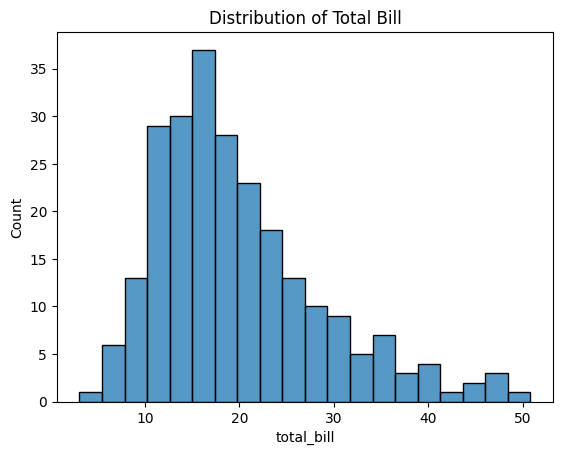

In [ ]:
# VISUALIZATION:-

#TOTAL BILL DISTRIBUTION.
sns.histplot(df["total_bill"],bins=20)
plt.title("Distribution of Total Bill")
plt.show()


CONCLUSION:- Most total bills falls within a moderate spending range.

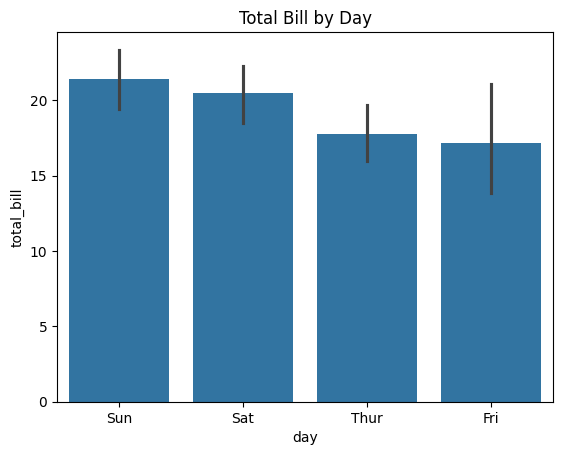

In [ ]:

# DAY WISE REVENUE.
sns.barplot(x="day",y="total_bill",data=df)
plt.title("Total Bill by Day")
plt.show()

CONCLUSION:- Weekend days appear to generate higher customer spending rather than weekdays.

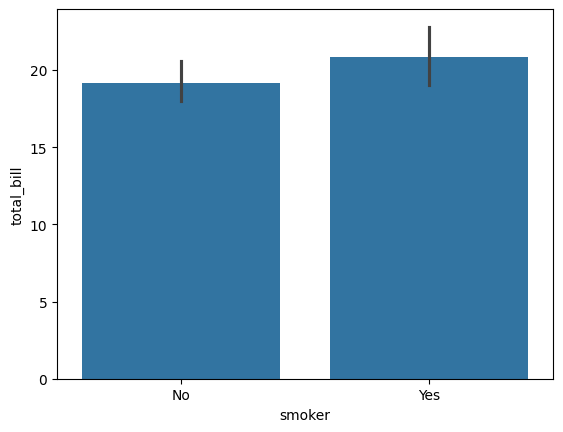

In [ ]:
# SMOKERS vs NON-SMOKERS.
sns.barplot(x="smoker",y="total_bill",data=df)
plt.title = "Total bill by Smokers"
plt.show()

CONCLUSION:- Spending patterns show slight variations between smokers and non smokers.

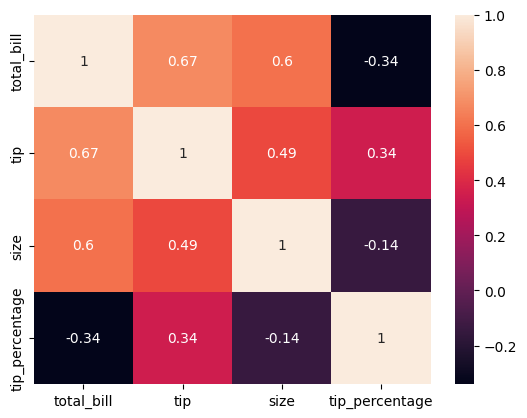

In [ ]:
# CORRELATION
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

CONCLUSION:- Observed a positive relationships between total bill and tip amount

# FINAL INSIGHTS:-

* Dinner customers spend more than lunch customers.
* Weekend days generate higher revenue than
weekdays.
* There is a strong positive relationship between total bill and tip amount.
* Larger groups tend to leave higher total tips.

